In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("Diffusion Modelleri — DDPM Matematiği")
print("=" * 45)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Forward process — veriyi nasıl bozarız?")
print("2. Reverse process — gürültüden veri nasıl üretiriz?")
print("3. ELBO ve eğitim objektivisi türetimi")
print("4. Noise prediction vs score matching")
print("5. Sıfırdan DDPM implement et")
print()
print("Anahtar: 'Yavaşça boz, yavaşça geri getir'")
print("Stable Diffusion, DALL-E 3, Sora hepsinin temeli!")

torch.manual_seed(42)
np.random.seed(42)

Diffusion Modelleri — DDPM Matematiği

Bugün cevaplayacağımız sorular:
1. Forward process — veriyi nasıl bozarız?
2. Reverse process — gürültüden veri nasıl üretiriz?
3. ELBO ve eğitim objektivisi türetimi
4. Noise prediction vs score matching
5. Sıfırdan DDPM implement et

Anahtar: 'Yavaşça boz, yavaşça geri getir'
Stable Diffusion, DALL-E 3, Sora hepsinin temeli!


Beta schedule:
β_1 = 0.000100
β_T = 0.020000

ᾱ_t değerleri:
  t=   0: ᾱ_t=0.999900, √ᾱ_t=0.9999, √(1-ᾱ_t)=0.0100
  t= 100: ᾱ_t=0.895141, √ᾱ_t=0.9461, √(1-ᾱ_t)=0.3238
  t= 250: ᾱ_t=0.521423, √ᾱ_t=0.7221, √(1-ᾱ_t)=0.6918
  t= 500: ᾱ_t=0.077797, √ᾱ_t=0.2789, √(1-ᾱ_t)=0.9603
  t= 750: ᾱ_t=0.003300, √ᾱ_t=0.0574, √(1-ᾱ_t)=0.9983
  t= 999: ᾱ_t=0.000040, √ᾱ_t=0.0064, √(1-ᾱ_t)=1.0000


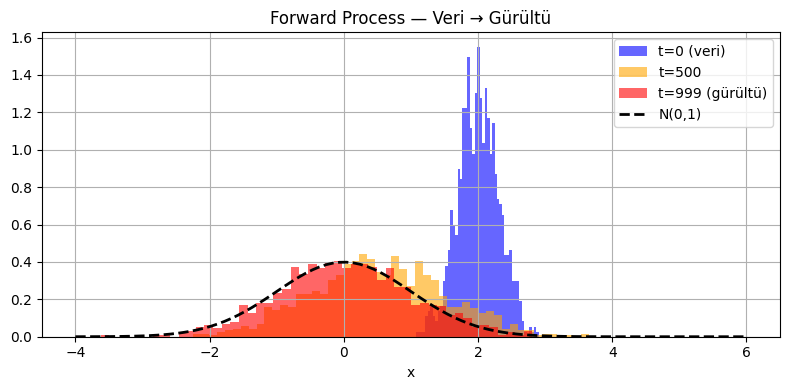

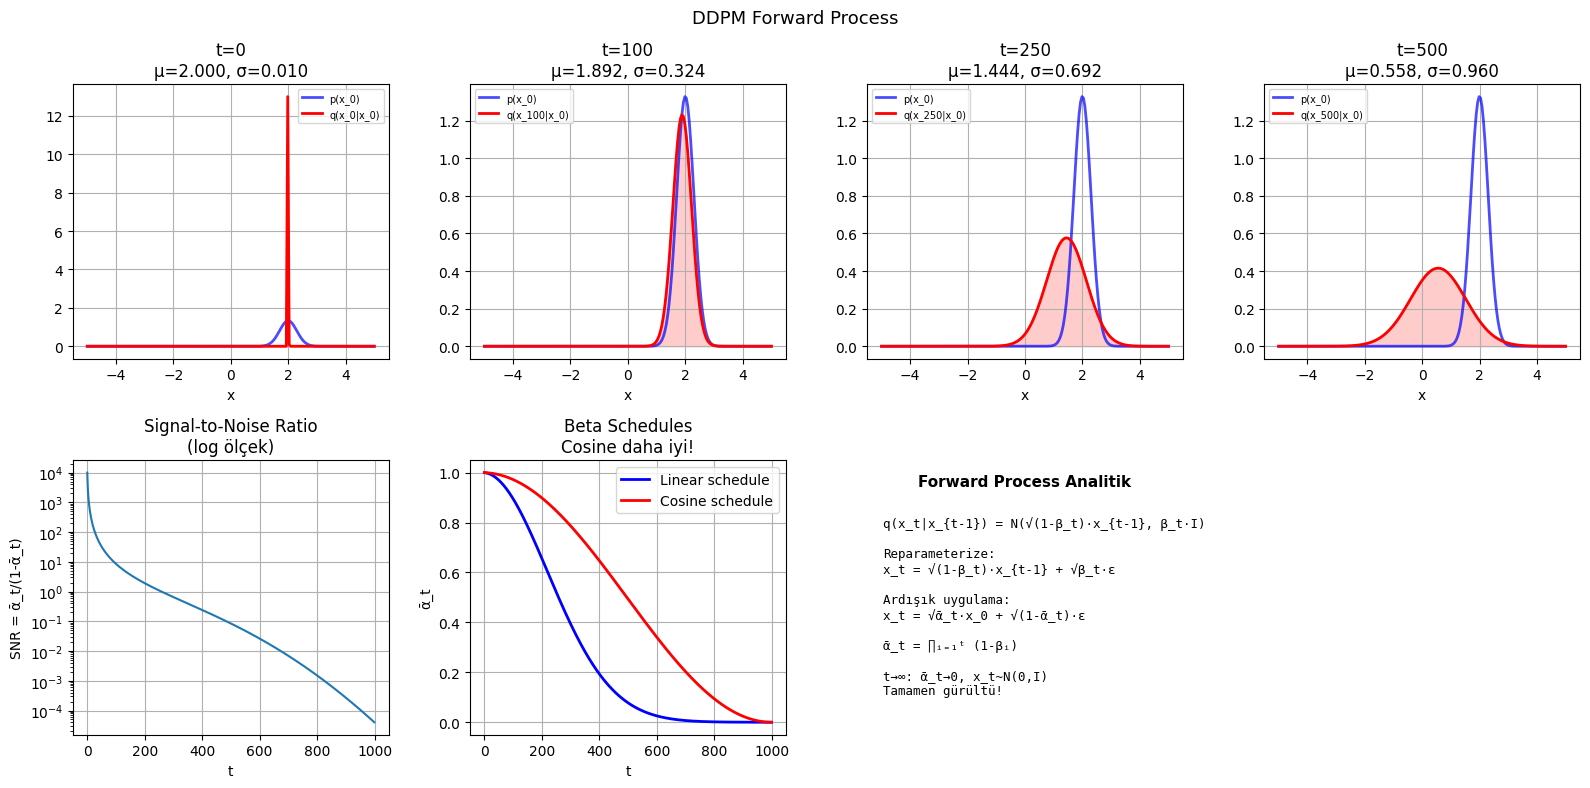

<Figure size 640x480 with 0 Axes>

In [2]:
# FORWARD PROCESS — VERİYİ GÜRÜLTÜYE DÖNÜŞTÜR
#
# q(x_t | x_{t-1}) = N(x_t; √(1-β_t) * x_{t-1}, β_t * I)
#
# Her adımda biraz gürültü ekle
# T adım sonra tamamen Gaussian gürültü
#
# Güzel özellik: Herhangi bir t için direkt örnekleme!
# q(x_t | x_0) = N(x_t; √ᾱ_t * x_0, (1-ᾱ_t) * I)
# ᾱ_t = Π_{s=1}^{t} (1-β_s)

# Beta schedule
T = 1000  # toplam adım sayısı
beta_start = 0.0001
beta_end = 0.02

# Linear schedule
betas = torch.linspace(beta_start, beta_end, T)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)  # ᾱ_t
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

print("Beta schedule:")
print(f"β_1 = {betas[0]:.6f}")
print(f"β_T = {betas[-1]:.6f}")
print(f"\nᾱ_t değerleri:")
for t in [0, 100, 250, 500, 750, 999]:
    print(f"  t={t:4d}: ᾱ_t={alphas_cumprod[t]:.6f}, "
          f"√ᾱ_t={sqrt_alphas_cumprod[t]:.4f}, "
          f"√(1-ᾱ_t)={sqrt_one_minus_alphas_cumprod[t]:.4f}")

# Forward process görselleştirme
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Basit 1D örnek
x_0 = torch.tensor([2.0])  # Başlangıç noktası
timesteps_vis = [0, 100, 250, 500, 750, 999]

# Forward process adımları
def forward_sample(x_0, t, alphas_cumprod):
    """q(x_t | x_0) = N(√ᾱ_t * x_0, (1-ᾱ_t)*I)"""
    sqrt_alpha_bar = sqrt_alphas_cumprod[t]
    sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t]
    eps = torch.randn_like(x_0)
    return sqrt_alpha_bar * x_0 + sqrt_one_minus * eps, eps

# Görüntü üzerinde forward process simülasyonu
x_range = np.linspace(-5, 5, 200)

for i, t in enumerate(timesteps_vis[:4]):
    ax = axes[0, i]
    # x_0 dağılımı — dar Gaussian
    p_x0 = norm.pdf(x_range, 2.0, 0.3)
    # q(x_t|x_0) dağılımı
    mu_t = sqrt_alphas_cumprod[t].item() * 2.0
    sigma_t = sqrt_one_minus_alphas_cumprod[t].item()
    p_xt = norm.pdf(x_range, mu_t, max(sigma_t, 0.01))

    ax.plot(x_range, p_x0, 'b-', linewidth=2,
           label='p(x_0)', alpha=0.7)
    ax.plot(x_range, p_xt, 'r-', linewidth=2,
           label=f'q(x_{t}|x_0)')
    ax.fill_between(x_range, p_xt, alpha=0.2, color='red')
    ax.set_title(f"t={t}\nμ={mu_t:.3f}, σ={sigma_t:.3f}")
    ax.set_xlabel("x")
    ax.legend(fontsize=7)
    ax.grid(True)

# SNR (Signal-to-Noise Ratio)
snr = alphas_cumprod / (1 - alphas_cumprod)
axes[1,0].semilogy(range(T), snr.numpy())
axes[1,0].set_title("Signal-to-Noise Ratio\n(log ölçek)")
axes[1,0].set_xlabel("t")
axes[1,0].set_ylabel("SNR = ᾱ_t/(1-ᾱ_t)")
axes[1,0].grid(True)

# Beta schedules karşılaştırması
t_range = torch.arange(T).float()
linear_betas = torch.linspace(beta_start, beta_end, T)
cosine_alphas_cumprod = torch.cos(
    (t_range/T + 0.008) / (1 + 0.008) * np.pi/2)**2
cosine_alphas_cumprod = cosine_alphas_cumprod / cosine_alphas_cumprod[0]

axes[1,1].plot(range(T), alphas_cumprod.numpy(),
              'b-', linewidth=2, label='Linear schedule')
axes[1,1].plot(range(T), cosine_alphas_cumprod.numpy(),
              'r-', linewidth=2, label='Cosine schedule')
axes[1,1].set_title("Beta Schedules\nCosine daha iyi!")
axes[1,1].set_xlabel("t")
axes[1,1].set_ylabel("ᾱ_t")
axes[1,1].legend()
axes[1,1].grid(True)

# Forward process analitik kanıt
axes[1,2].axis('off')
axes[1,2].text(0.5, 0.95, "Forward Process Analitik",
              ha='center', va='top', fontsize=11,
              fontweight='bold', transform=axes[1,2].transAxes)
proof_text = """
q(x_t|x_{t-1}) = N(√(1-β_t)·x_{t-1}, β_t·I)

Reparameterize:
x_t = √(1-β_t)·x_{t-1} + √β_t·ε

Ardışık uygulama:
x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε

ᾱ_t = ∏ᵢ₌₁ᵗ (1-βᵢ)

t→∞: ᾱ_t→0, x_t~N(0,I)
Tamamen gürültü!
"""
axes[1,2].text(0.05, 0.85, proof_text,
              ha='left', va='top', fontsize=9,
              transform=axes[1,2].transAxes,
              family='monospace')

# Örnekleme dağılımı
axes[1,3].axis('off')
samples_t0 = torch.randn(1000) * 0.3 + 2.0
samples_t500, _ = forward_sample(
    samples_t0.unsqueeze(1), 500, alphas_cumprod)
samples_t999, _ = forward_sample(
    samples_t0.unsqueeze(1), 999, alphas_cumprod)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(samples_t0.numpy(), bins=50, alpha=0.6,
        color='blue', density=True, label='t=0 (veri)')
ax2.hist(samples_t500.numpy().flatten(), bins=50, alpha=0.6,
        color='orange', density=True, label='t=500')
ax2.hist(samples_t999.numpy().flatten(), bins=50, alpha=0.6,
        color='red', density=True, label='t=999 (gürültü)')

x_gauss = np.linspace(-4, 6, 100)
ax2.plot(x_gauss, norm.pdf(x_gauss, 0, 1), 'k--',
        linewidth=2, label='N(0,1)')
ax2.set_title("Forward Process — Veri → Gürültü")
ax2.set_xlabel("x")
ax2.legend()
ax2.grid(True)
plt.tight_layout()

plt.figure(fig.number)
plt.suptitle("DDPM Forward Process", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(fig2.number)
plt.show()